# 03 · Démarrage NASA POWER

Ce notebook sert de démonstration de téléchargement léger sur un point au Cameroun.

Remarque: il nécessite une connexion internet fonctionnelle.


## Point d'exemple

On utilise ici Yaoundé comme point de démonstration.


In [1]:
from pathlib import Path
from agrometflow.climate.power import PowerDownloader

output_dir = Path("training_outputs/power")
output_dir.mkdir(parents=True, exist_ok=True)

dl = PowerDownloader(verbose=True)

In [4]:
variables = [
    ("T2M_MAX", "TMAX"),
    ("T2M_MIN", "TMIN"),
    ("PRECTOTCORR", "PR"),
]

dl.download(
    start_date="1991-06-01",
    end_date="2020-06-10",
    variables=variables,
    points=[(3.848, 11.502)],
    output_dir=output_dir,
)

[INFO] 2026-04-06 20:20:28 — Fetching POWER data for (3.848, 11.502)
[INFO] 2026-04-06 20:20:31 — Data saved to training_outputs/power/power_19910601_20200610.csv


In [5]:
power_df = dl.extract(variables=["TMAX", "TMIN", "PR"])
power_df.head(10)

,Date,lat,lon,TMAX,TMIN,PR
0,1991-06-01,3.848,11.502,28.65,20.20,1.97
1,1991-06-02,3.848,11.502,28.92,20.48,2.27
2,1991-06-03,3.848,11.502,27.61,21.13,2.54
3,1991-06-04,3.848,11.502,26.93,21.29,1.90
4,1991-06-05,3.848,11.502,27.30,20.37,0.02
5,1991-06-06,3.848,11.502,28.14,20.52,0.00
6,1991-06-07,3.848,11.502,27.90,20.41,0.00
7,1991-06-08,3.848,11.502,27.17,20.82,0.00
8,1991-06-09,3.848,11.502,28.37,20.50,0.00
9,1991-06-10,3.848,11.502,28.34,20.44,2.89


## Questions

- Quelles variables sont directement exploitables pour un modèle de culture ?
- Quelles variables manquent encore ?
- Quelle comparaison voudrais-tu faire entre POWER et une station locale ?


## Étape pédagogique 1 - Préparer les données

Objectif:
- partir du tableau journalier avec une date au format `yyyymmdd`
- identifier les colonnes météo (températures, pluie, autres)
- créer des variables de calendrier (année, mois, décade) utilisables pour les agrégations

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Source des données: on utilise power_df s'il existe déjà dans le notebook
csv_path = Path("training_outputs/power/power_19910101_20201231.csv")
df = pd.read_csv(csv_path)

# 2) Détection de la colonne date
date_candidates = ["Date", "date", "DATE", "yyyymmdd", "YYYYMMDD"]
date_col = next((c for c in date_candidates if c in df.columns), None)
if date_col is None:
    raise ValueError("Aucune colonne date trouvée. Colonnes testées: Date/date/yyyymmdd")

# 3) Conversion de la date (priorité au format yyyymmdd)
df[date_col] = pd.to_datetime(df[date_col].astype(str), format="%Y%m%d", errors="coerce")
if df[date_col].isna().all():
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)

# 4) Colonnes numériques météo
numeric_cols = df.select_dtypes(include="number").columns.tolist()
meteo_cols = [c for c in numeric_cols if c.lower() not in {"lat", "lon"}]

# 5) Identification de la pluie et des températures
precip_names = {"PR", "PRECIP", "RAIN", "RR", "PRECTOTCORR", "P"}
precip_col = next((c for c in meteo_cols if c.upper() in precip_names), None)

temp_candidates = [c for c in meteo_cols if c.upper() in {"TMAX", "TMIN", "TMEAN", "TAVG", "TMOY", "TEMP"}]
if "TMAX" in df.columns and "TMIN" in df.columns and "TMEAN" not in df.columns:
    df["TMEAN"] = (df["TMAX"] + df["TMIN"]) / 2
    meteo_cols.append("TMEAN")
    if "TMEAN" not in temp_candidates:
        temp_candidates.append("TMEAN")

temp_plot_col = "TMEAN" if "TMEAN" in df.columns else (temp_candidates[0] if temp_candidates else None)

# 6) Variables calendrier
s = df[date_col]
df["year"] = s.dt.year
df["month"] = s.dt.month
df["day"] = s.dt.day
df["decade_in_month"] = np.where(df["day"] <= 10, 1, np.where(df["day"] <= 20, 2, 3))
df["dekad"] = (df["month"] - 1) * 3 + df["decade_in_month"]

# 7) Règle d'agrégation: somme pour pluie, moyenne pour le reste
agg_map = {c: ("sum" if c == precip_col else "mean") for c in meteo_cols}

print("Date utilisée:", date_col)
print("Colonne pluie:", precip_col)
print("Colonne température pour les graphiques:", temp_plot_col)
print("Colonnes agrégées:", meteo_cols)
print(df.head())

Date utilisée: date
Colonne pluie: PR
Colonne température pour les graphiques: TMEAN
Colonnes agrégées: ['TMAX', 'TMIN', 'PR', 'TMEAN']
        date   TMAX   TMIN    PR    lat     lon   TMEAN  year  month  day  \
0 1991-01-01  26.81  16.31  0.80  3.848  11.502  21.560  1991      1    1   
1 1991-01-02  26.66  16.37  0.06  3.848  11.502  21.515  1991      1    2   
2 1991-01-03  27.25  16.64  0.00  3.848  11.502  21.945  1991      1    3   
3 1991-01-04  27.73  18.05  0.46  3.848  11.502  22.890  1991      1    4   
4 1991-01-05  27.70  17.44  0.80  3.848  11.502  22.570  1991      1    5   

   decade_in_month  dekad  
0                1      1  
1                1      1  
2                1      1  
3                1      1  
4                1      1  


In [12]:
df.head()

,date,TMAX,TMIN,PR,lat,lon,TMEAN,year,month,day,decade_in_month,dekad
0,1991-01-01,26.81,16.31,0.80,3.848,11.502,21.560,1991,1,1,1,1
1,1991-01-02,26.66,16.37,0.06,3.848,11.502,21.515,1991,1,2,1,1
2,1991-01-03,27.25,16.64,0.00,3.848,11.502,21.945,1991,1,3,1,1
3,1991-01-04,27.73,18.05,0.46,3.848,11.502,22.890,1991,1,4,1,1
4,1991-01-05,27.70,17.44,0.80,3.848,11.502,22.570,1991,1,5,1,1


## Étape pédagogique 2 - Moyennes décadaires (et somme pluie)

Dans cette étape:
- on calcule les statistiques **par décade pour chaque année**
- puis on calcule la **climatologie décadaire** (moyenne de toutes les années)
- pour la pluie, la règle est une **somme par décade**

Aperçu décadal par année:


,year,dekad,TMAX,TMIN,PR,TMEAN
0,1991,1,28.096000,18.328000,4.92,23.212000
1,1991,2,28.633000,19.780000,0.01,24.206500
2,1991,3,29.288182,19.996364,9.39,24.642273
3,1991,4,29.453000,20.263000,0.12,24.858000
4,1991,5,30.066000,20.891000,0.94,25.478500
5,1991,6,29.342500,21.301250,15.54,25.321875
6,1991,7,28.684000,21.353000,19.66,25.018500
7,1991,8,28.074000,21.157000,45.91,24.615500
8,1991,9,28.679091,21.351818,3.86,25.015455
9,1991,10,27.603000,20.772000,101.38,24.187500


Aperçu climatologie décadaire (moyenne interannuelle):


,dekad,year,TMAX,TMIN,PR,TMEAN
0,1,2005.5,28.782500,18.926133,3.977667,23.854317
1,2,2005.5,29.191667,19.370267,2.815333,24.280967
2,3,2005.5,29.356091,20.016848,6.182667,24.686470
3,4,2005.5,29.945867,20.496033,7.446000,25.220950
4,5,2005.5,29.893700,20.768733,9.291333,25.331217
5,6,2005.5,29.758458,21.218995,16.891333,25.488727
6,7,2005.5,29.380433,21.377033,24.466333,25.378733
7,8,2005.5,28.668767,21.464800,41.617333,25.066783
8,9,2005.5,28.434303,21.425939,49.045000,24.930121
9,10,2005.5,28.060667,21.435667,56.108333,24.748167


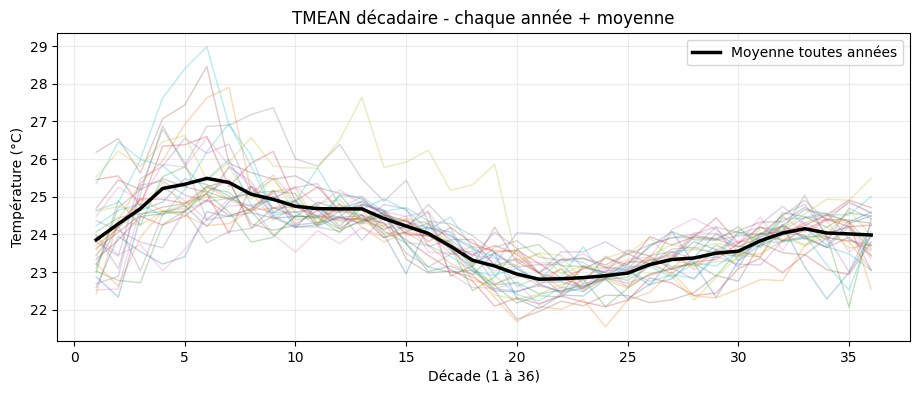

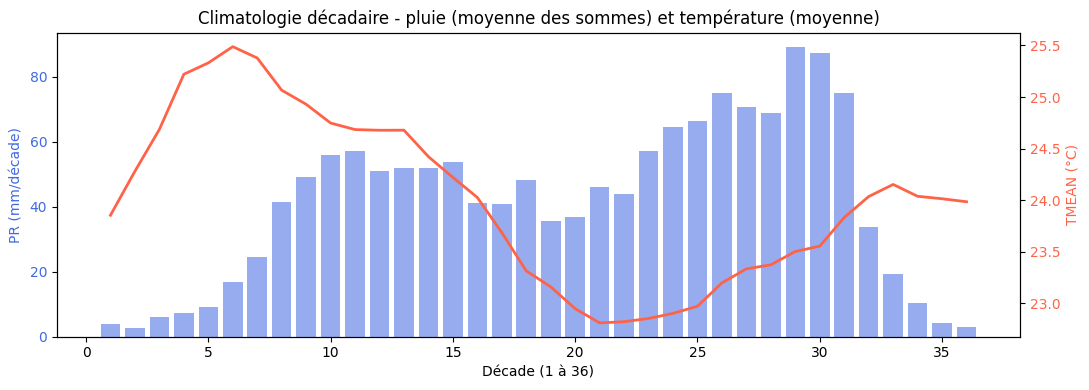

In [14]:
# Agrégation décadaire par année
# Règle: pluie en SOMME par décade et autres variables en MOYENNE
decadal_year = (
    df.groupby(["year", "dekad"], as_index=False)
      .agg(agg_map)
      .sort_values(["year", "dekad"])
)

# Climatologie décadaire (ensemble des années)
# Règle demandée: MOYENNE interannuelle de chaque décade,
# y compris pour la pluie (moyenne des sommes décadaires annuelles)
decadal_all_years = (
    decadal_year.groupby("dekad", as_index=False)
               .mean(numeric_only=True)
               .sort_values("dekad")
)

print("Aperçu décadal par année:")
display(decadal_year.head(12))
print("Aperçu climatologie décadaire (moyenne interannuelle):")
display(decadal_all_years.head(12))

# Plot 1: courbes décadaires pour chaque année (température)
if temp_plot_col is not None:
    plt.figure(figsize=(11, 4))
    for year, g in decadal_year.groupby("year"):
        plt.plot(g["dekad"], g[temp_plot_col], alpha=0.30, linewidth=1)
    plt.plot(decadal_all_years["dekad"], decadal_all_years[temp_plot_col], color="black", linewidth=2.5, label="Moyenne toutes années")
    plt.title(f"{temp_plot_col} décadaire - chaque année + moyenne")
    plt.xlabel("Décade (1 à 36)")
    plt.ylabel("Température (°C)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

# Plot 2: climatologie décadaire pluie + température (barres + courbe)
if (precip_col is not None) and (temp_plot_col is not None):
    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.bar(decadal_all_years["dekad"], decadal_all_years[precip_col], color="royalblue", alpha=0.55, label=precip_col)
    ax1.set_xlabel("Décade (1 à 36)")
    ax1.set_ylabel(f"{precip_col} (mm/décade)", color="royalblue")
    ax1.tick_params(axis="y", labelcolor="royalblue")

    ax2 = ax1.twinx()
    ax2.plot(decadal_all_years["dekad"], decadal_all_years[temp_plot_col], color="tomato", linewidth=2, label=temp_plot_col)
    ax2.set_ylabel(f"{temp_plot_col} (°C)", color="tomato")
    ax2.tick_params(axis="y", labelcolor="tomato")

    plt.title("Climatologie décadaire - pluie (moyenne des sommes) et température (moyenne)")
    fig.tight_layout()
    plt.show()

## Étape pédagogique 3 - Agrégation mensuelle

Ici on calcule:
- une série mensuelle **par année**
- une climatologie mensuelle **toutes années confondues**
- pluie en somme mensuelle, températures et autres en moyenne

Aperçu mensuel par année:


,year,month,TMAX,TMIN,PR,TMEAN
0,1991,1,28.692258,19.388387,14.32,24.040323
1,1991,2,29.640357,20.783929,16.60,25.212143
2,1991,3,28.485484,21.289355,69.43,24.887419
3,1991,4,27.691333,21.017333,167.27,24.354333
4,1991,5,26.852258,20.741290,173.69,23.796774
5,1991,6,26.981667,20.332333,100.29,23.657000
6,1991,7,25.840968,19.275806,51.99,22.558387
7,1991,8,26.119677,19.211290,25.24,22.665484
8,1991,9,27.420333,19.879333,95.11,23.649833
9,1991,10,26.347419,19.576774,105.46,22.962097


Aperçu climatologie mensuelle:


,month,year,TMAX,TMIN,PR,TMEAN
0,1,2005.5,29.118022,19.456430,12.975667,24.287226
1,2,2005.5,29.875541,20.805255,33.628667,25.340398
2,3,2005.5,28.815140,21.422699,115.128667,25.118919
3,4,2005.5,27.945889,21.461489,164.202000,24.703689
4,5,2005.5,27.598602,21.268871,157.712333,24.433737
5,6,2005.5,26.890567,20.460744,130.253333,23.675656
6,7,2005.5,26.254484,19.681312,118.997333,22.967898
7,8,2005.5,26.165473,19.556387,165.796333,22.860930
8,9,2005.5,26.350456,19.986111,212.172667,23.168283
9,10,2005.5,26.584301,20.374978,245.344000,23.479640


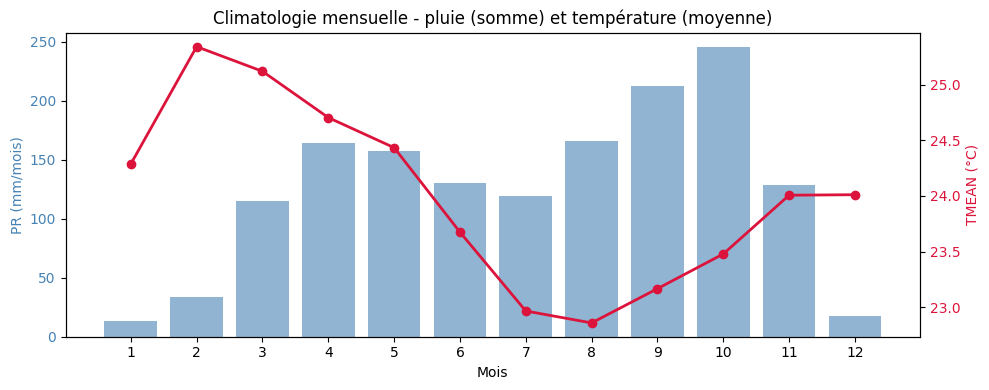

In [15]:
monthly_year = (
    df.groupby(["year", "month"], as_index=False)
      .agg(agg_map)
      .sort_values(["year", "month"])
)

monthly_all_years = (
    monthly_year.groupby("month", as_index=False)
               .mean(numeric_only=True)
               .sort_values("month")
)

print("Aperçu mensuel par année:")
display(monthly_year.head(12))
print("Aperçu climatologie mensuelle:")
display(monthly_all_years)

if (precip_col is not None) and (temp_plot_col is not None):
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(monthly_all_years["month"], monthly_all_years[precip_col], color="steelblue", alpha=0.6)
    ax1.set_xlabel("Mois")
    ax1.set_ylabel(f"{precip_col} (mm/mois)", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax1.set_xticks(range(1, 13))

    ax2 = ax1.twinx()
    ax2.plot(monthly_all_years["month"], monthly_all_years[temp_plot_col], color="crimson", marker="o", linewidth=2)
    ax2.set_ylabel(f"{temp_plot_col} (°C)", color="crimson")
    ax2.tick_params(axis="y", labelcolor="crimson")

    plt.title("Climatologie mensuelle - pluie (somme) et température (moyenne)")
    fig.tight_layout()
    plt.show()

## Étape pédagogique 4 - Agrégation annuelle

On passe à l'échelle annuelle:
- pluie en **somme annuelle**
- températures et autres variables en **moyenne annuelle**

Aperçu annuel:


,year,TMAX,TMIN,PR,TMEAN
0,1991,27.630822,20.092329,967.70,23.861575
1,1992,27.594836,19.791530,1576.15,23.693183
2,1993,26.989370,19.964904,1778.24,23.477137
3,1994,26.870164,19.964055,1664.29,23.417110
4,1995,27.093342,20.244493,1745.55,23.668918
5,1996,26.874781,20.056230,1707.73,23.465505
6,1997,27.264411,20.078438,1413.83,23.671425
7,1998,28.367726,20.707644,1680.36,24.537685
8,1999,27.254219,20.254740,1397.41,23.754479
9,2000,27.651831,20.107213,1659.92,23.879522


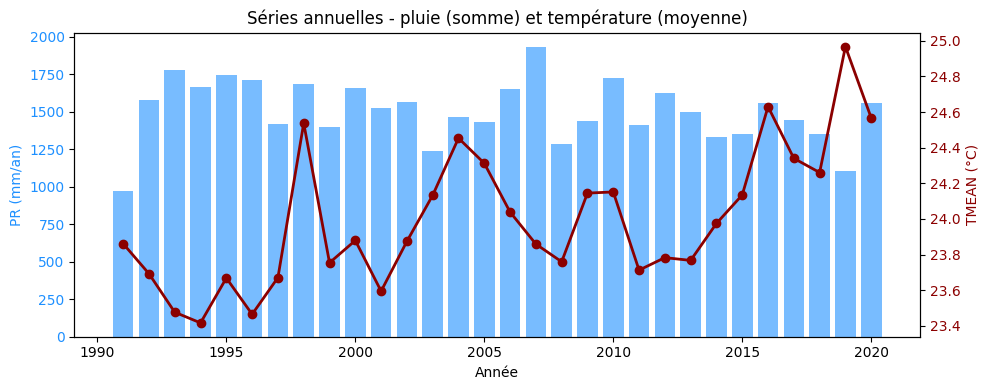

In [16]:
annual = (
    df.groupby("year", as_index=False)
      .agg(agg_map)
      .sort_values("year")
)

print("Aperçu annuel:")
display(annual)

if (precip_col is not None) and (temp_plot_col is not None):
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(annual["year"], annual[precip_col], color="dodgerblue", alpha=0.6)
    ax1.set_xlabel("Année")
    ax1.set_ylabel(f"{precip_col} (mm/an)", color="dodgerblue")
    ax1.tick_params(axis="y", labelcolor="dodgerblue")

    ax2 = ax1.twinx()
    ax2.plot(annual["year"], annual[temp_plot_col], color="darkred", marker="o", linewidth=2)
    ax2.set_ylabel(f"{temp_plot_col} (°C)", color="darkred")
    ax2.tick_params(axis="y", labelcolor="darkred")

    plt.title("Séries annuelles - pluie (somme) et température (moyenne)")
    fig.tight_layout()
    plt.show()

## Étape pédagogique 5 - Courbe ombrothermique (P = 2T)

Principe:
- on utilise la climatologie mensuelle (toutes années)
- on trace `T` et `P/2` sur le même axe (équivalent à la règle P = 2T)
- zones sèches quand `P < 2T`

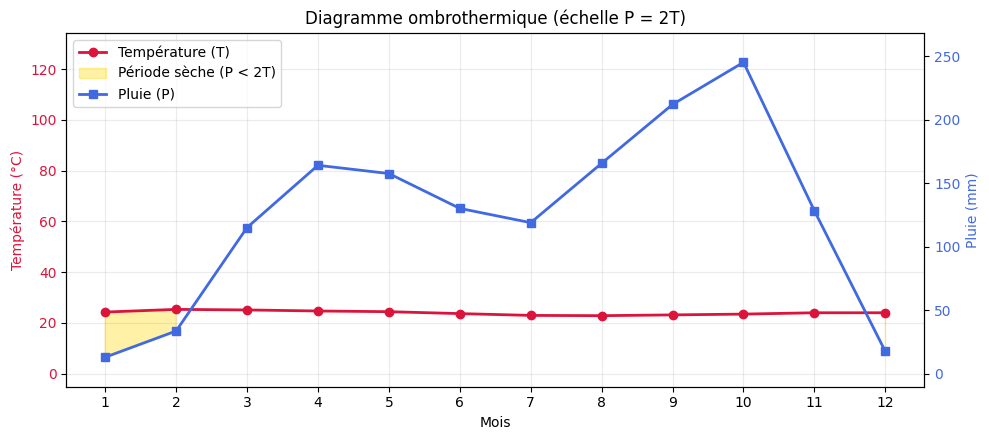

In [19]:
if (precip_col is None) or (temp_plot_col is None):
    raise ValueError("Impossible de tracer la courbe ombrothermique: colonne pluie ou température non trouvée.")

ombro = monthly_all_years[["month", precip_col, temp_plot_col]].copy()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax2 = ax.twinx()

# Données inchangées: T sur l'axe gauche, P sur l'axe droit
ax.plot(ombro["month"], ombro[temp_plot_col], color="crimson", marker="o", linewidth=2, label="Température (T)")
ax2.plot(ombro["month"], ombro[precip_col], color="royalblue", marker="s", linewidth=2, label="Pluie (P)")

# Échelle ombrothermique explicite: 50 mm de pluie correspondent à 25 °C
# soit 2 mm pour 1 °C.
mm_per_deg = 2.0

t_min = float(ombro[temp_plot_col].min())
t_max = float(ombro[temp_plot_col].max())
p_as_t_min = float((ombro[precip_col] / mm_per_deg).min())
p_as_t_max = float((ombro[precip_col] / mm_per_deg).max())

y_min = min(t_min, p_as_t_min)
y_max = max(t_max, p_as_t_max)
margin = max(1.0, 0.1 * (y_max - y_min))

ax.set_ylim(y_min - margin, y_max + margin)
left_min, left_max = ax.get_ylim()
ax2.set_ylim(mm_per_deg * left_min, mm_per_deg * left_max)

# Zones sèches: P < 2T
p_on_temp_scale = ombro[precip_col] / mm_per_deg
dry_mask = ombro[precip_col] < (mm_per_deg * ombro[temp_plot_col])
ax.fill_between(
    ombro["month"],
    p_on_temp_scale,
    ombro[temp_plot_col],
    where=dry_mask,
    color="gold",
    alpha=0.35,
    label="Période sèche (P < 2T)",
)

ax.set_xticks(range(1, 13))
ax.set_xlabel("Mois")
ax.set_ylabel("Température (°C)", color="crimson")
ax2.set_ylabel("Pluie (mm)", color="royalblue")
ax.tick_params(axis="y", labelcolor="crimson")
ax2.tick_params(axis="y", labelcolor="royalblue")
ax.set_title("Diagramme ombrothermique (50 mm = 25 °C, soit P = 2T)")
ax.grid(alpha=0.25)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")

plt.tight_layout()
plt.show()